In [25]:
import pandas as pd

df = pd.read_csv("All_Stocks_Data.csv")
print(df.shape)
print(df.columns)

(2435, 459)
Index(['Unnamed: 0', 'symbol', '2021-11-04', '2021-11-03', '2021-11-02',
       '2021-10-29', '2021-10-28', '2021-10-27', '2021-10-26', '2021-10-25',
       ...
       '2020-01-14', '2020-01-13', '2020-01-10', '2020-01-09', '2020-01-08',
       '2020-01-07', '2020-01-06', '2020-01-03', '2020-01-02', '2020-01-01'],
      dtype='object', length=459)


In [26]:
print(df['symbol'].unique())

['20MICRONS' '21STCENMGM' '3IINFOTECH' ... '812GS2020' '657GS2033'
 'ICICI1298']


In [27]:
df = df[df['symbol'] == '20MICRONS']

In [28]:
print(df.shape)
df.head()

(1, 459)


,Unnamed: 0,symbol,2021-11-04,2021-11-03,2021-11-02,2021-10-29,2021-10-28,2021-10-27,2021-10-26,2021-10-25,...,2020-01-14,2020-01-13,2020-01-10,2020-01-09,2020-01-08,2020-01-07,2020-01-06,2020-01-03,2020-01-02,2020-01-01
0,closing_price,20MICRONS,59.75,58.4,58.55,58.55,59.35,60.15,57.85,56.9,...,36.05,35.9,34.3,33.4,32.7,33.2,32.8,35.05,35.55,35.8


In [29]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

df = df.set_index('symbol').T

print(df.shape)   # MUST be (dates, 1)

df.index = pd.to_datetime(df.index)

df.columns = ['Close']

df.sort_index(inplace=True)

df.head()

(457, 1)


,Close
2020-01-01,35.80
2020-01-02,35.55
2020-01-03,35.05
2020-01-06,32.80
2020-01-07,33.20


In [30]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(df)

train_size = int(len(df_scaled)*0.8)

train_data = df_scaled[:train_size]
test_data = df_scaled[train_size:]

X_train = np.array(range(len(train_data)))
y_train = train_data.flatten()

X_test = np.array(range(len(train_data), len(df_scaled)))
y_test = test_data.flatten()

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr_model = LinearRegression()
lr_model.fit(X_train.reshape(-1,1), y_train)

lr_predictions = lr_model.predict(X_test.reshape(-1,1))
lr_predictions = scaler.inverse_transform(lr_predictions.reshape(-1,1))

lr_mse = mean_squared_error(
    scaler.inverse_transform(test_data),
    lr_predictions
)

print("Linear Regression MSE:", lr_mse)

Linear Regression MSE: 172.87876649697657


In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10

X_train_lstm, y_train_lstm = create_sequences(train_data, seq_length)
X_test_lstm, y_test_lstm = create_sequences(test_data, seq_length)

X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], seq_length, 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], seq_length, 1)

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length,1)),
    LSTM(50),
    Dense(25),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")

lstm_model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=16)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0217
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0034
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0032
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0034
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026
Epoch 13/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022
Epoch 14/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026
Epoch 15/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020
Epoch 

In [33]:
lstm_predictions = lstm_model.predict(X_test_lstm)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

from sklearn.metrics import mean_squared_error

lstm_mse = mean_squared_error(
    scaler.inverse_transform(y_test_lstm.reshape(-1,1)),
    lstm_predictions
)

print("LSTM MSE:", lstm_mse)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step
LSTM MSE: 5.660339468519705


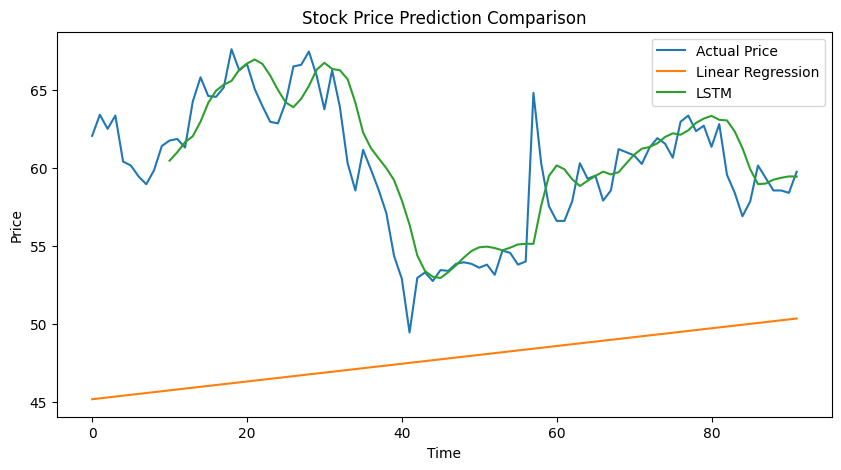

In [39]:
import matplotlib.pyplot as plt

# Actual prices
actual = scaler.inverse_transform(test_data)

plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual Price")
plt.plot(lr_predictions, label="Linear Regression")
plt.plot(range(10, len(lstm_predictions)+10), lstm_predictions, label="LSTM")

plt.legend()
plt.title("Stock Price Prediction Comparison")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()